In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.6/112.6 GB disk)


## Fine-tune YOLO11 on custom dataset

In [ ]:
# !pip install ultralytics
# !pip install roboflow

# !mkdir {HOME}/datasets
# %cd {HOME}/datasets

# from google.colab import userdata
# from roboflow import Roboflow


# rf = Roboflow(api_key="FD0YlvmVm5MWv5yRBMcI")
# project = rf.workspace("everyday-glee1").project("everyday-ultimate-main")
# version = project.version(2)
# dataset = version.download("yolov11")

In [ ]:
!pip install ultralytics
!pip install roboflow

!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow


rf = Roboflow(api_key="3qduNDzsBSXEa73QGWfB")
project = rf.workspace("household-j10i9").project("household-khbd4")
version = project.version(1)
dataset = version.download("yolov11")



/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to household-1 in yolov11:: 100%|██████████| 47162/47162 [00:06<00:00, 7237.18it/s]


/content


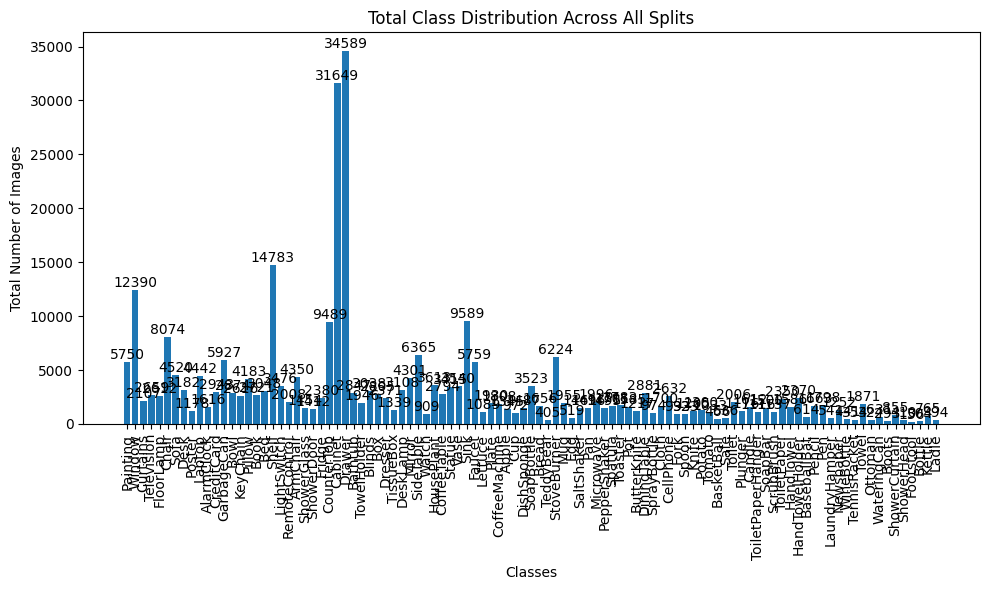

In [ ]:
import os
import matplotlib.pyplot as plt
import yaml

%cd {HOME}

# Define paths for the dataset
dataset_splits = ["train", "valid", "test"]
class_counts_per_split = {}

# Count occurrences of each class in all splits
for split in dataset_splits:
    label_folder = os.path.join(dataset.location, split, "labels")
    class_counts = {}
    for filename in os.listdir(label_folder):
        with open(os.path.join(label_folder, filename), 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                if class_id not in class_counts:
                    class_counts[class_id] = 0
                class_counts[class_id] += 1
    class_counts_per_split[split] = class_counts

# Load class names from data.yaml
with open(f'{dataset.location}/data.yaml', 'r') as f:
    data = yaml.safe_load(f)
class_names = data['names']

# Aggregate class counts across all splits
total_class_counts = {class_id: 0 for class_id in class_counts_per_split["train"].keys()}
for split in dataset_splits:
    for class_id, count in class_counts_per_split[split].items():
        total_class_counts[class_id] += count

# Create a bar chart to show the total distribution of classes across all splits
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(total_class_counts)), list(total_class_counts.values()))
plt.xticks(range(len(total_class_counts)), [class_names[i] for i in total_class_counts.keys()], rotation=90)
plt.xlabel("Classes")
plt.ylabel("Total Number of Images")
plt.title("Total Class Distribution Across All Splits")

# Add text annotations on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()


/content
Class               Train          Valid          Test           
-----------------------------------------------------------------
Painting            4974           534            242            
Window              10846          1038           506            
Curtains            1870           166            71             
Television          2339           222            98             
FloorLamp           2270           233            109            
Chair               6958           735            381            
Sofa                3953           381            186            
Desk                2765           274            143            
Poster              1040           98             40             
Laptop              3869           395            178            
AlarmClock          1395           161            60             
CreditCard          2578           243            122            
GarbageCan          5183           483            261            
B

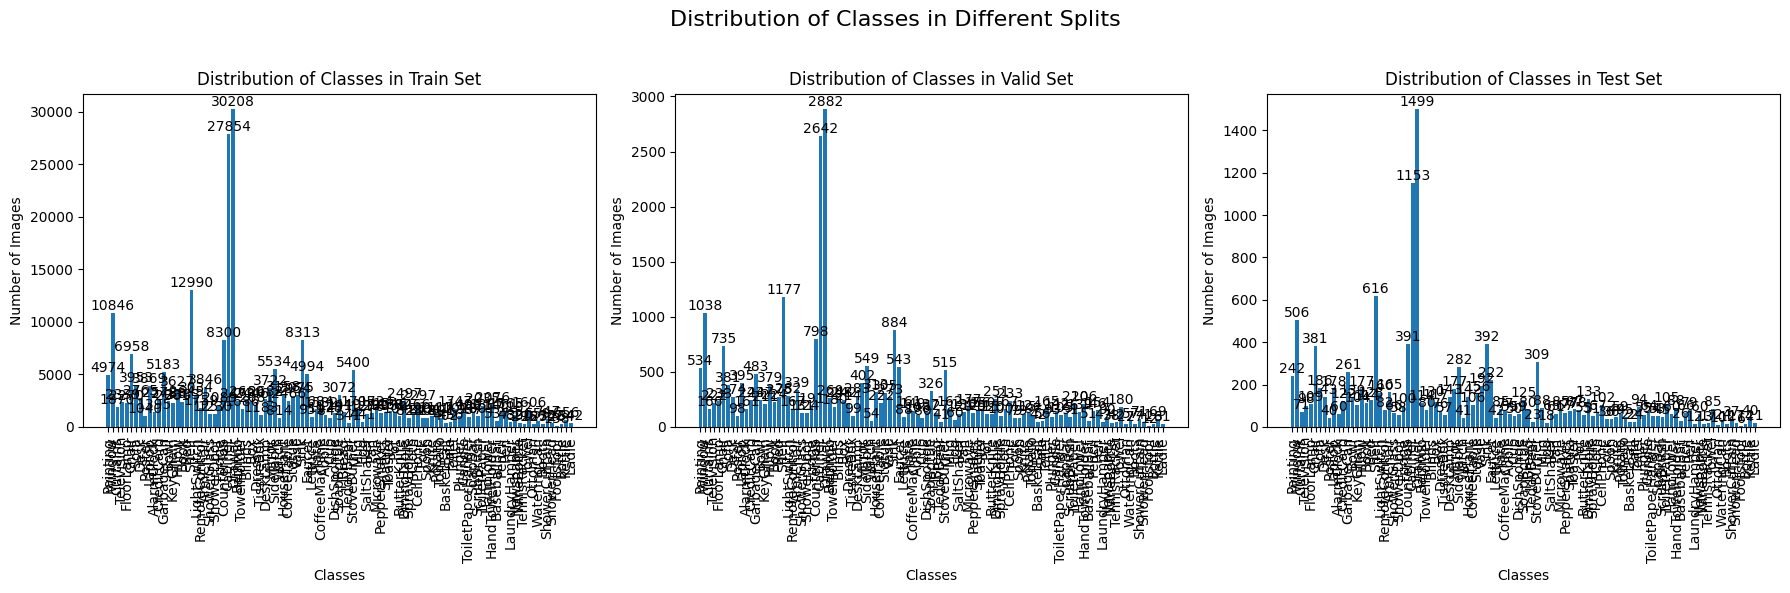

In [ ]:
import os
import matplotlib.pyplot as plt
import yaml
from collections import OrderedDict
import matplotlib.image as mpimg
import numpy as np

%cd {HOME}

def count_classes(folder):
    """Counts the occurrences of each class in a dataset folder."""
    label_folder = os.path.join(folder, "labels")
    class_counts = {}
    for filename in os.listdir(label_folder):
        with open(os.path.join(label_folder, filename), 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                if class_id not in class_counts:
                    class_counts[class_id] = 0
                class_counts[class_id] += 1
    return class_counts

# Assuming 'dataset.location' is defined and holds the base directory of the dataset
dataset_splits = ["train", "valid", "test"]
class_counts_per_split = {}

for split in dataset_splits:
    folder = os.path.join(dataset.location, split)
    class_counts_per_split[split] = count_classes(folder)

# Load class names from data.yaml
with open(f'{dataset.location}/data.yaml', 'r') as f:
    data = yaml.safe_load(f)
class_names = data['names']

# Print class counts side by side
# Create an ordered set of all classes in all splits to have a common order and make sure all classes are displayed
all_classes = OrderedDict()
for split in dataset_splits:
    for class_id in class_counts_per_split[split].keys():
        if class_id not in all_classes:
             all_classes[class_id] = None

# Print header with split names
header = "Class".ljust(20)
for split in dataset_splits:
    header += f"{split.capitalize()}".ljust(15)
print(header)
print("-" * len(header))

for class_id in all_classes.keys():
    line = class_names[class_id].ljust(20)
    for split in dataset_splits:
        count = class_counts_per_split[split].get(class_id, 0)
        line += f"{count}".ljust(15)
    print(line)
print()

# Create bar charts for each split side by side
fig_bars, axes_bars = plt.subplots(1, len(dataset_splits), figsize=(6 * len(dataset_splits), 6))
fig_bars.suptitle("Distribution of Classes in Different Splits\n", fontsize=16)

for i, split in enumerate(dataset_splits):
    class_counts = class_counts_per_split[split]
    ax = axes_bars[i] if len(dataset_splits) > 1 else axes_bars

    # Use all_classes keys to order the bars
    ordered_class_ids = list(all_classes.keys())
    ordered_counts = [class_counts.get(class_id, 0) for class_id in ordered_class_ids]

    bars = ax.bar(range(len(ordered_class_ids)), ordered_counts)
    ax.set_xticks(range(len(ordered_class_ids)))
    ax.set_xticklabels([class_names[i] for i in ordered_class_ids], rotation=90)
    ax.set_xlabel("Classes")
    ax.set_ylabel("Number of Images")
    ax.set_title(f"Distribution of Classes in {split.capitalize()} Set")

    # Add text annotations on top of each bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=20 imgsz=640 plots=True

/content
100% 5.35M/5.35M [00:00<00:00, 397MB/s]
New https://pypi.org/project/ultralytics/8.3.146 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/datasets/household-1/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    R_curve.png		  val_batch0_labels.jpg
confusion_matrix_normalized.png			    results.csv		  val_batch0_pred.jpg
confusion_matrix.png				    results.png		  val_batch1_labels.jpg
events.out.tfevents.1742197757.bd666cccb789.1168.0  train_batch0.jpg	  val_batch1_pred.jpg
F1_curve.png					    train_batch12910.jpg  val_batch2_labels.jpg
labels_correlogram.jpg				    train_batch12911.jpg  val_batch2_pred.jpg
labels.jpg					    train_batch12912.jpg  weights
P_curve.png					    train_batch1.jpg
PR_curve.png					    train_batch2.jpg


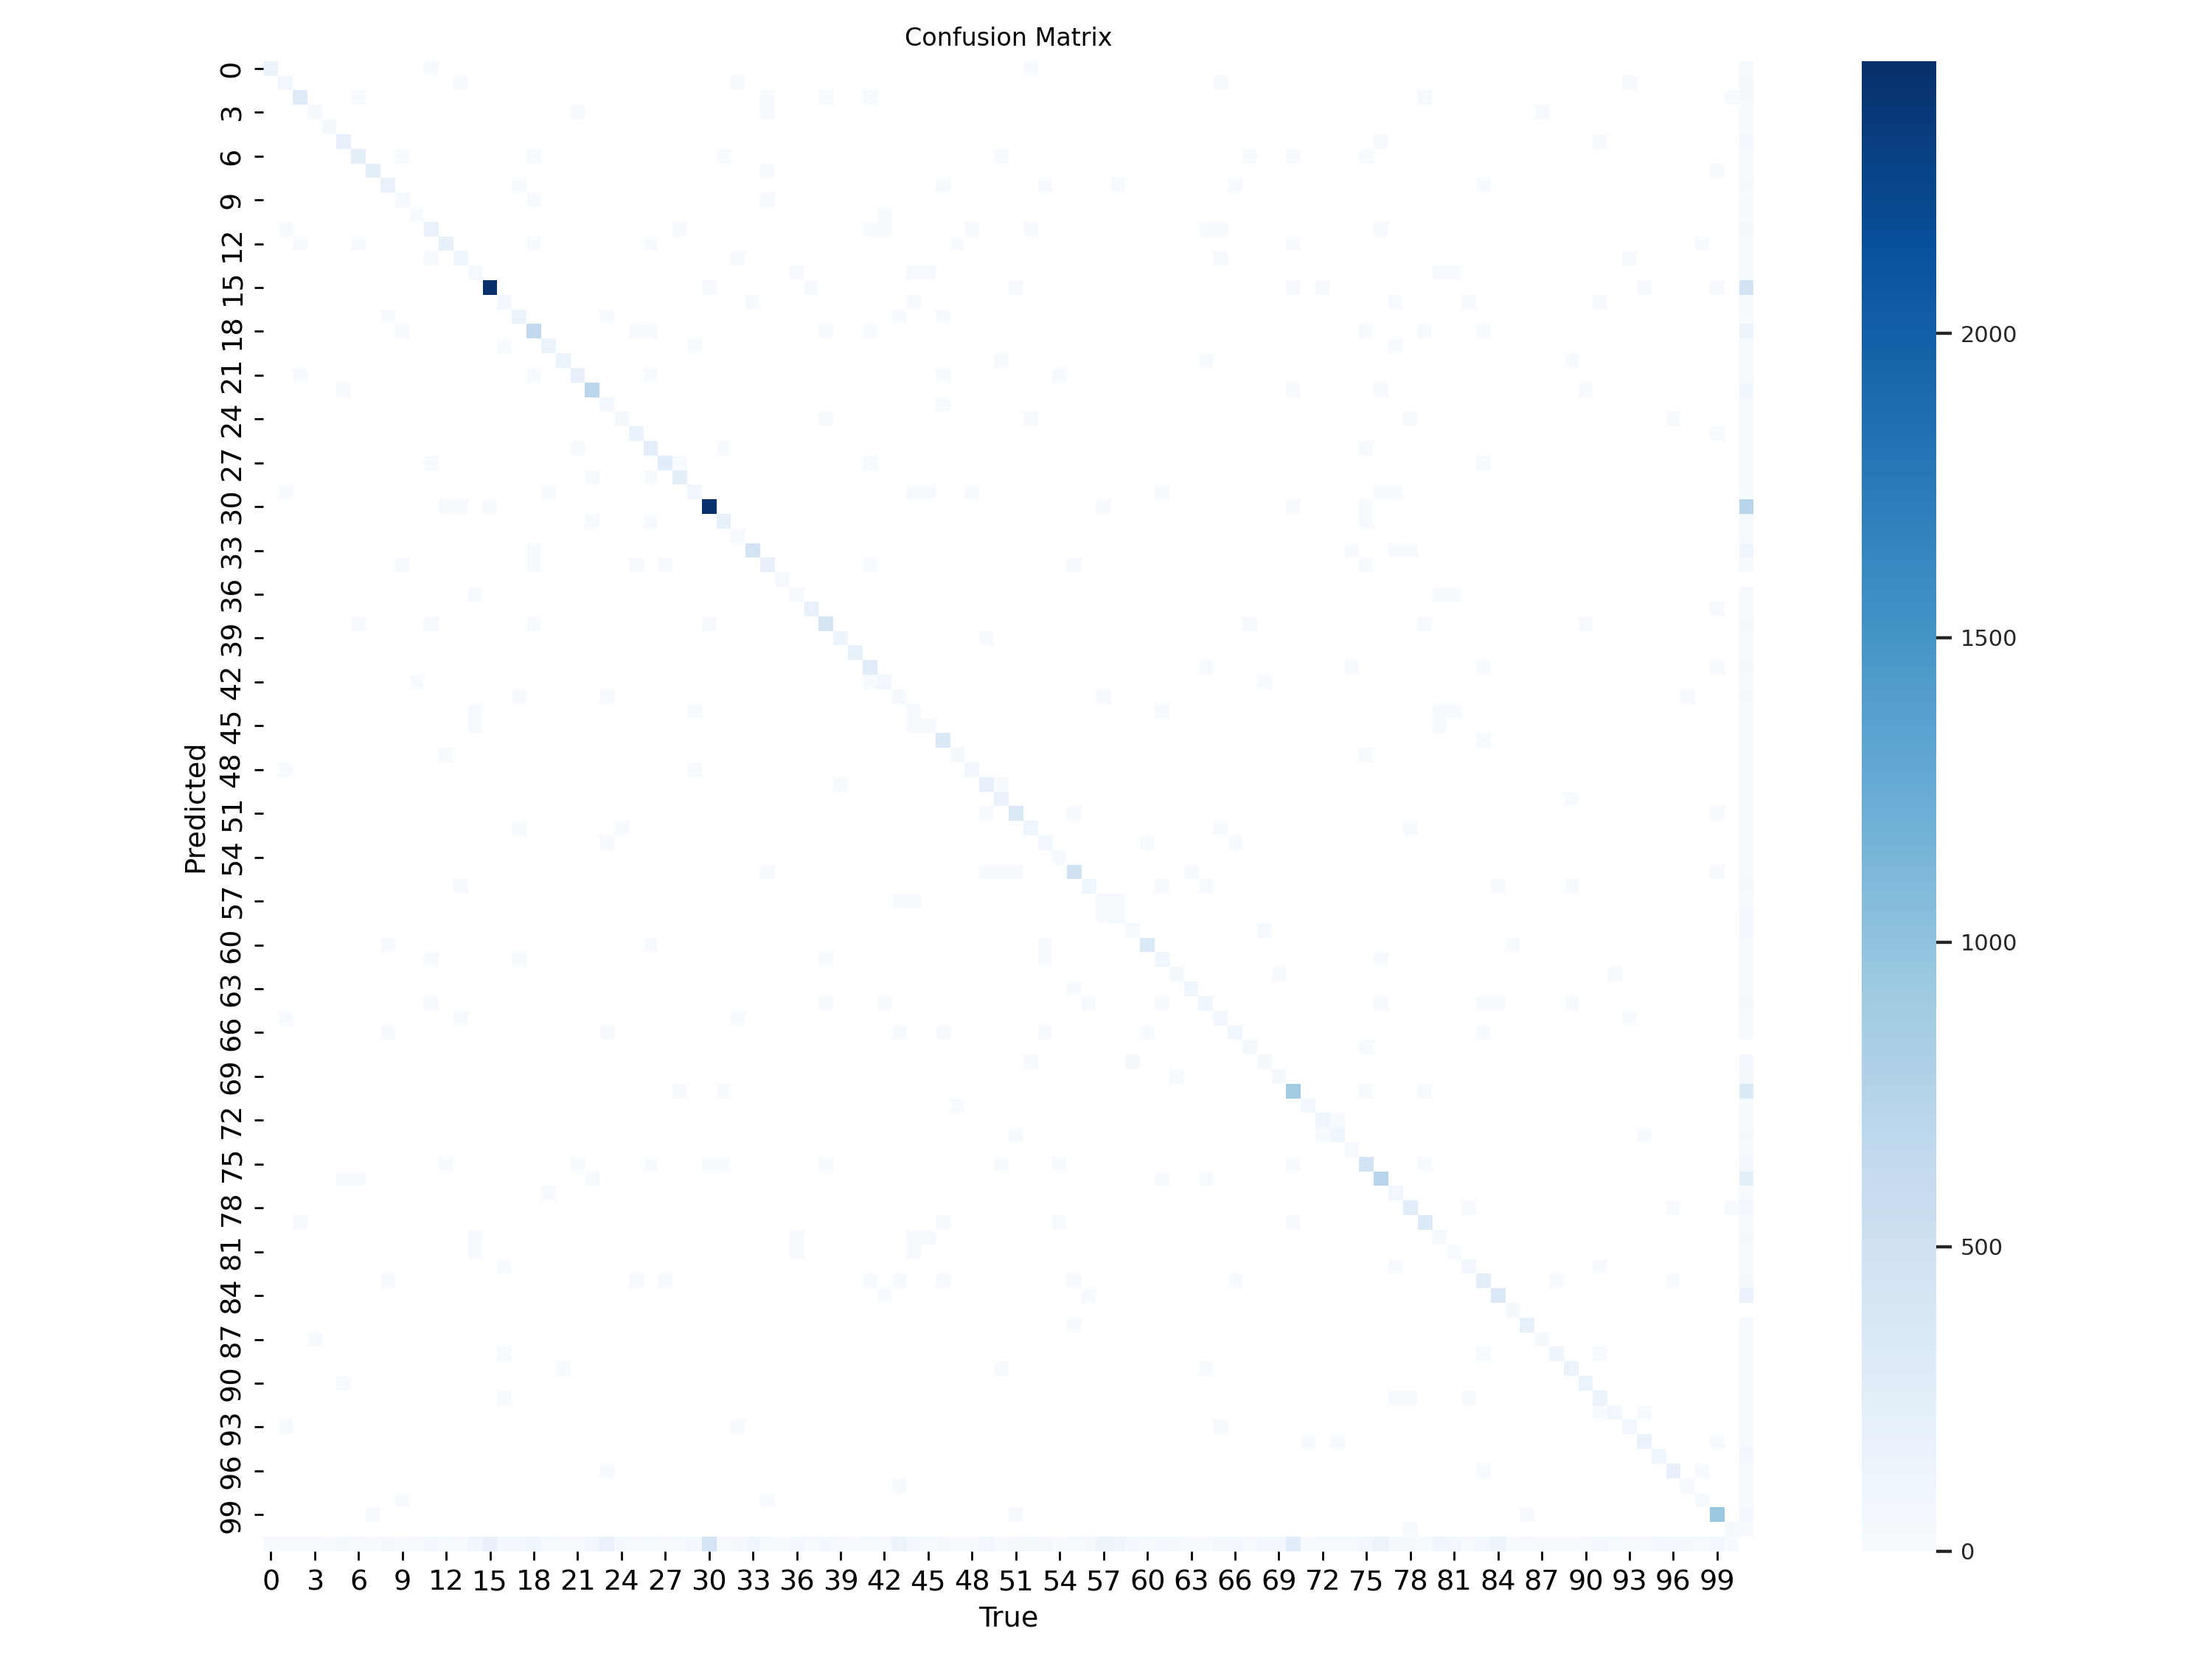

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=1000)

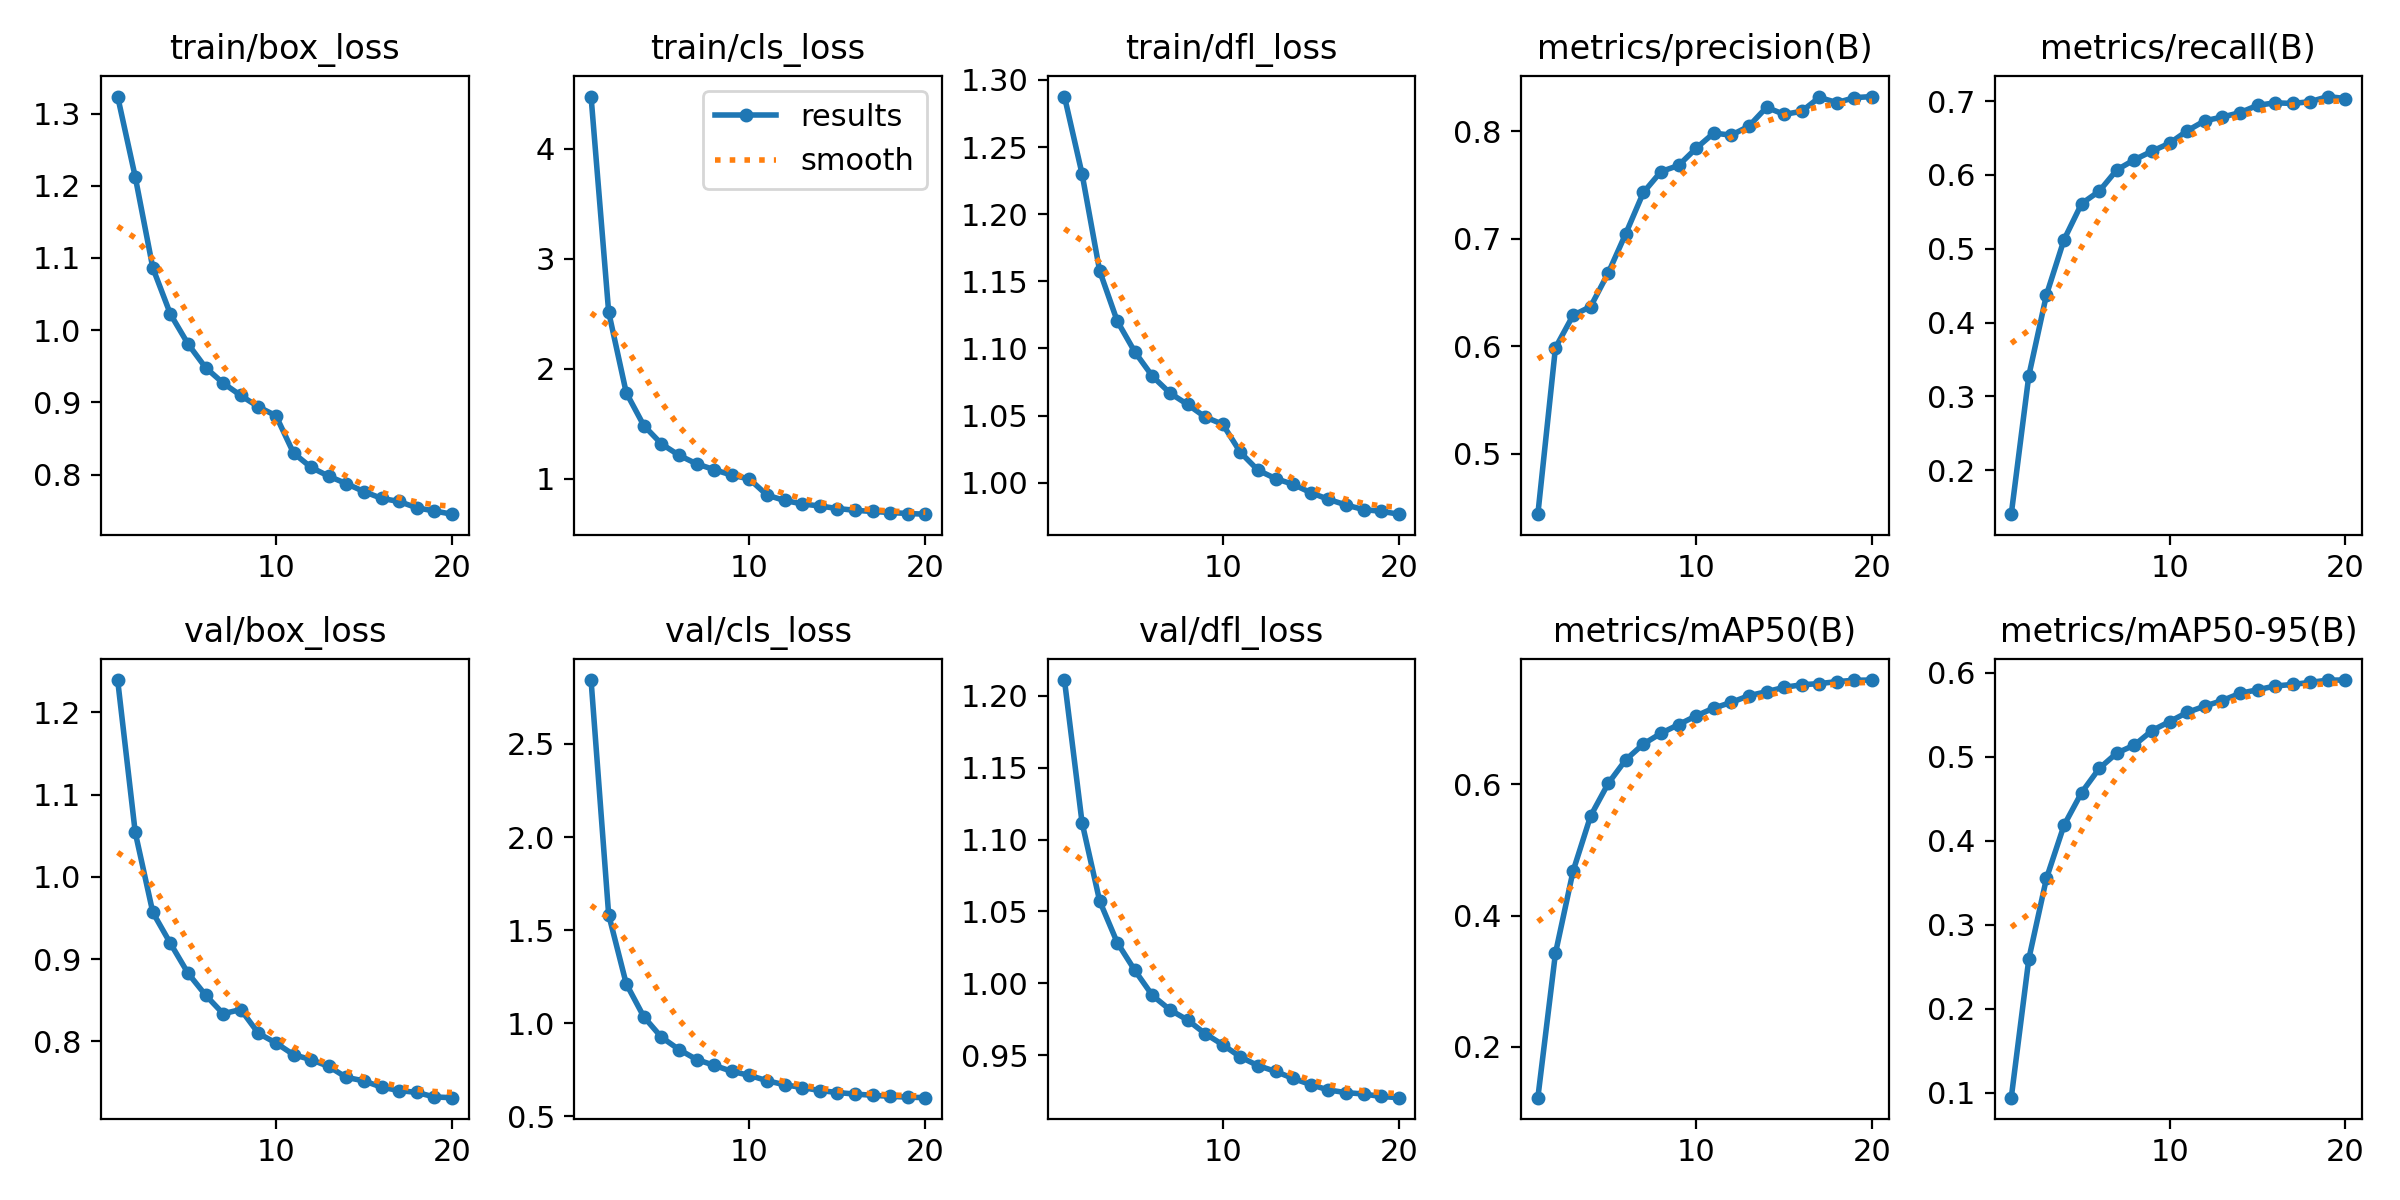

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=1000)

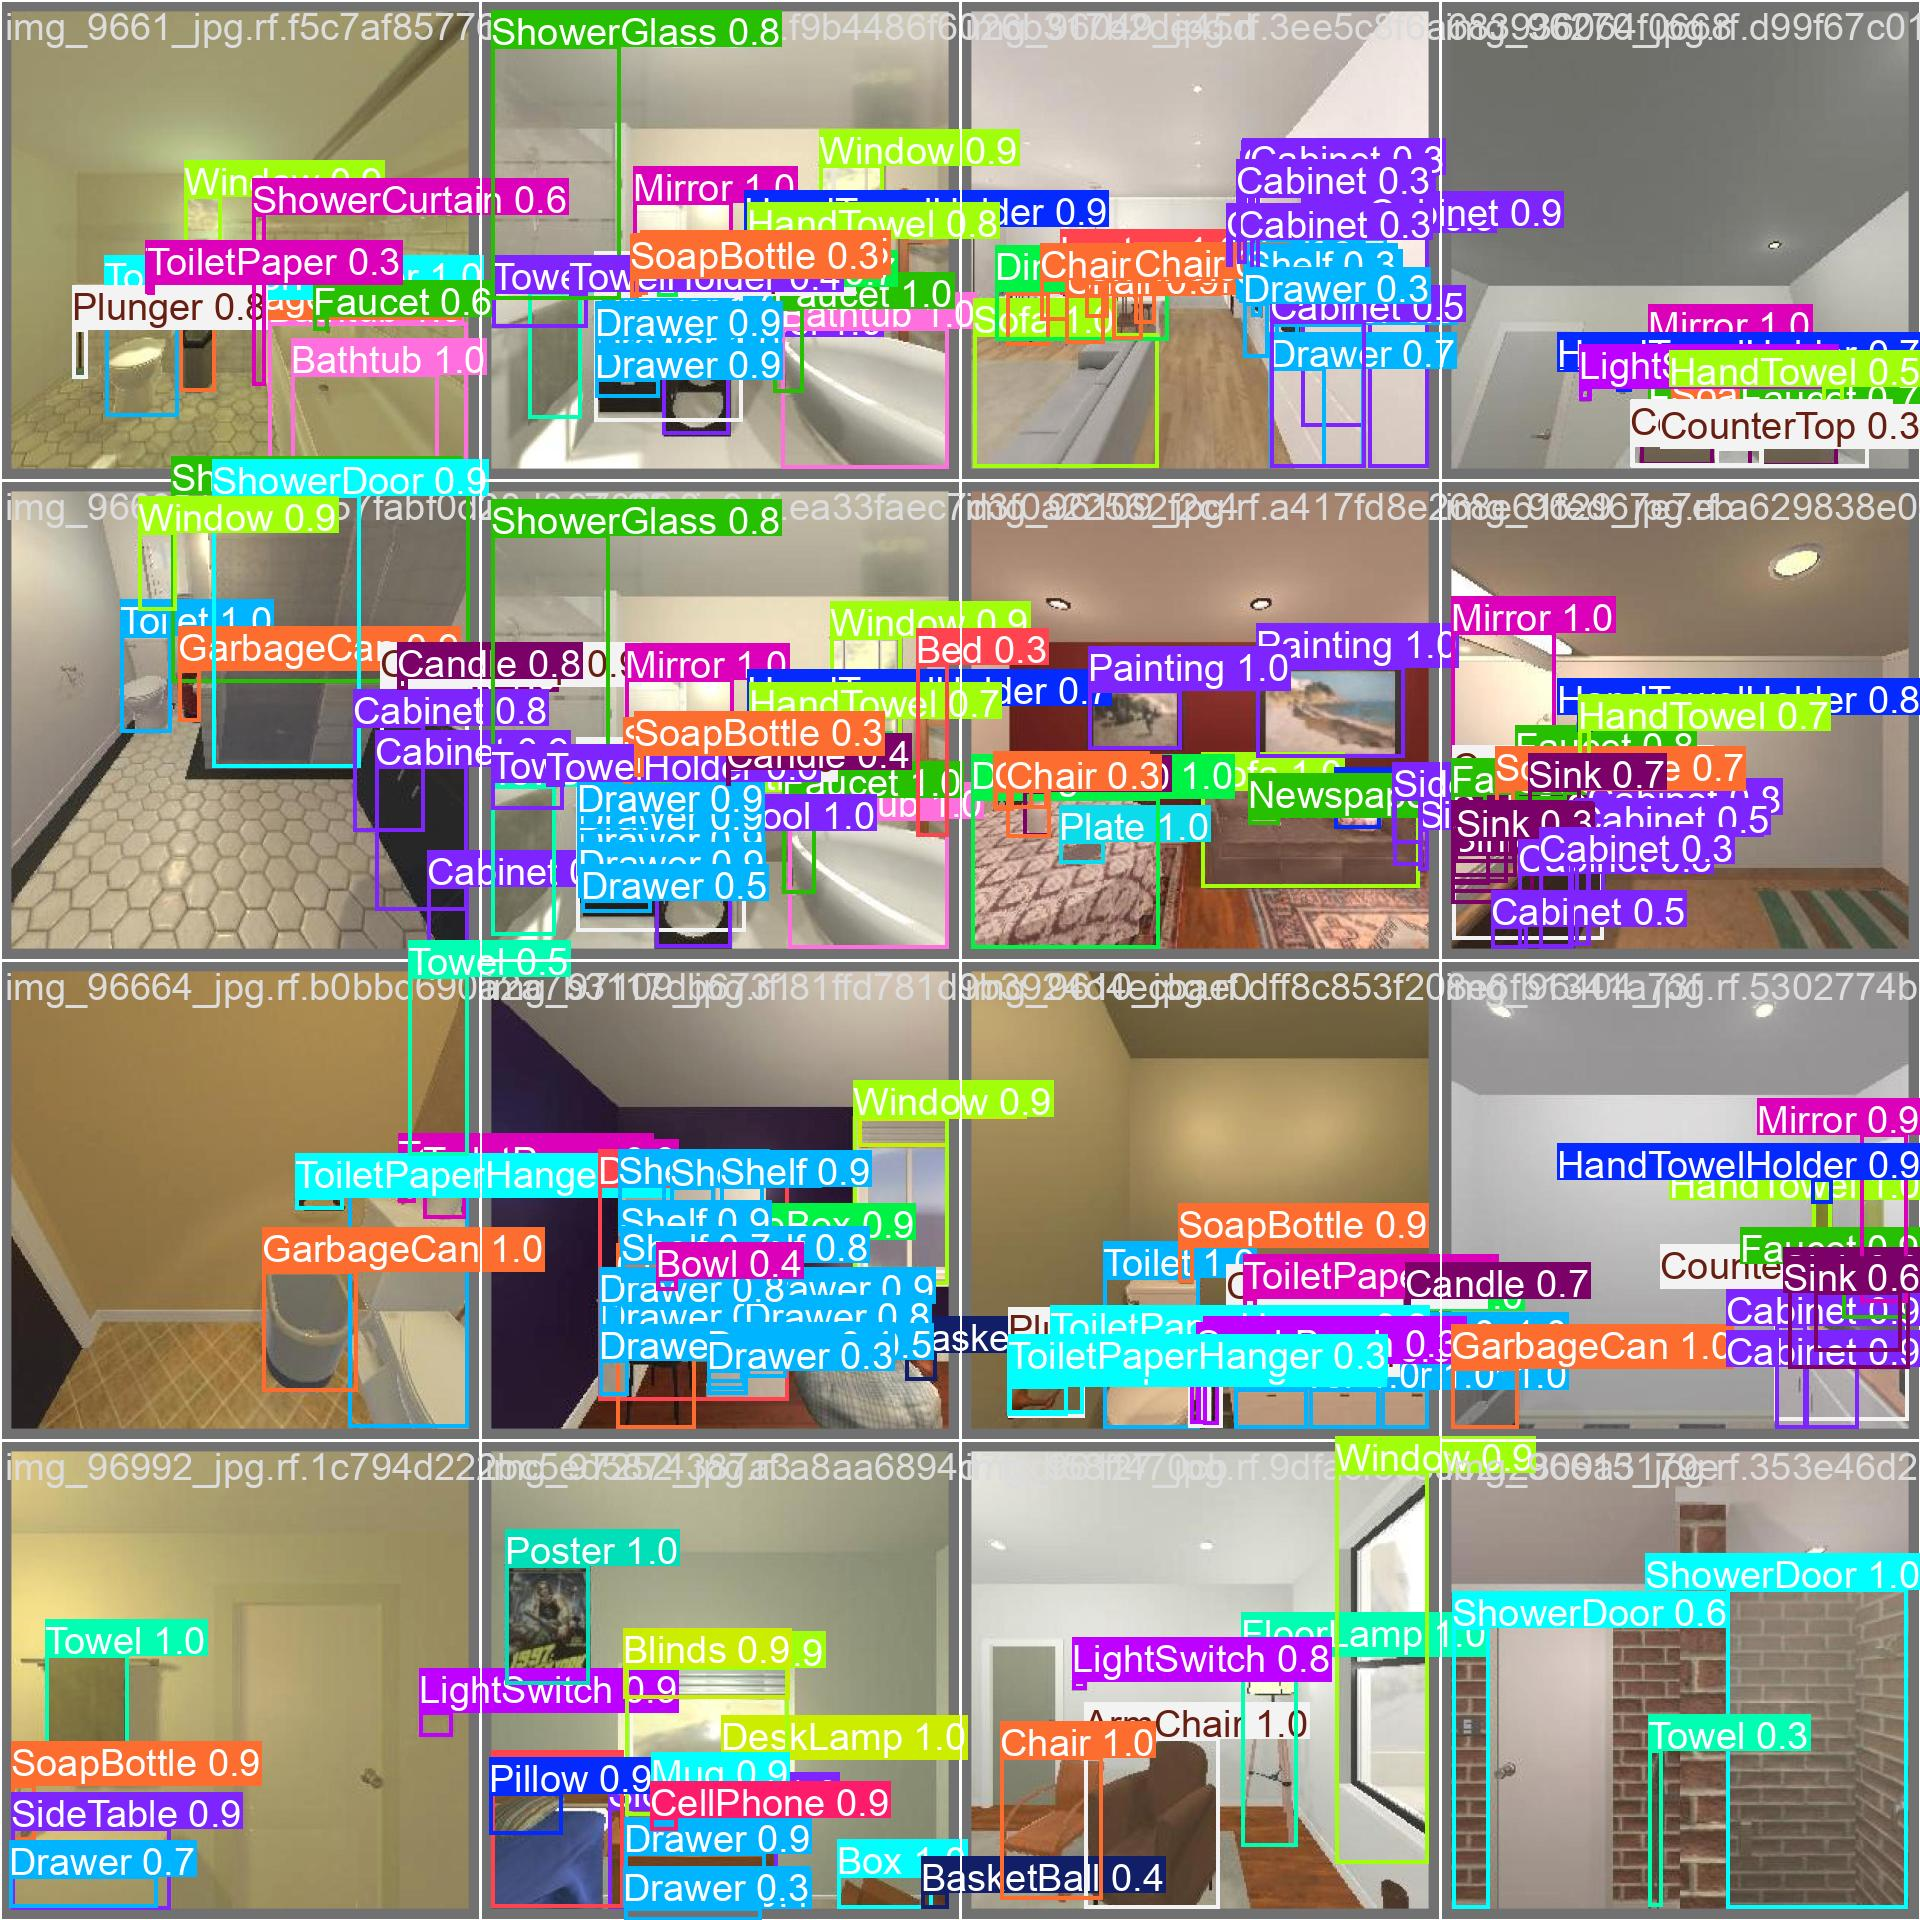

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=1000)

## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,647,891 parameters, 0 gradients, 6.6 GFLOPs
val: Scanning /content/datasets/household-1/valid/labels.cache... 1949 images, 0 backgrounds, 0 corrupt: 100% 1949/1949 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 122/122 [00:25<00:00,  4.75it/s]
                   all       1949      26885      0.833      0.705       0.76      0.592
            AlarmClock        160        161       0.88      0.882      0.946       0.72
                 Apple        108        108      0.675      0.713       0.72      0.508
              ArmChair        265        339      0.908      0.935      0.958      0.907
           BaseballBat         51         51      0.652      0.627      0.682      0.467
            BasketBall         42         42      0.961      0.929      0.956      0.751
               Bathtub        176   

## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,647,891 parameters, 0 gradients, 6.6 GFLOPs

image 1/971 /content/datasets/household-1/test/images/img_0_jpg.rf.58140f43ea824188acff6b358541ae2c.jpg: 640x640 1 ArmChair, 1 Boots, 1 Chair, 1 FloorLamp, 1 LightSwitch, 1 Window, 13.3ms
image 2/971 /content/datasets/household-1/test/images/img_10001_jpg.rf.5b0feec8947232fb5fa85ec5ca15fa30.jpg: 640x640 1 AlarmClock, 3 ArmChairs, 1 Bed, 1 DeskLamp, 1 LaundryHamper, 1 Mirror, 9.6ms
image 3/971 /content/datasets/household-1/test/images/img_100156_jpg.rf.671f2c84f34f5cf4f8179de8f1b21c07.jpg: 640x640 1 HandTowel, 1 HandTowelHolder, 1 Mirror, 1 ShowerGlass, 8.6ms
image 4/971 /content/datasets/household-1/test/images/img_100975_jpg.rf.61837b2530c00906d5aea5d131179556.jpg: 640x640 1 BasketBall, 1 Blinds, 1 Box, 1 Chair, 1 Desk, 9 Drawers, 1 GarbageCan, 6 Shelfs, 1 TissueBox, 1 Window, 8.3ms
image 5/971 /content/datasets/household

**NOTE:** Let's take a look at few results.

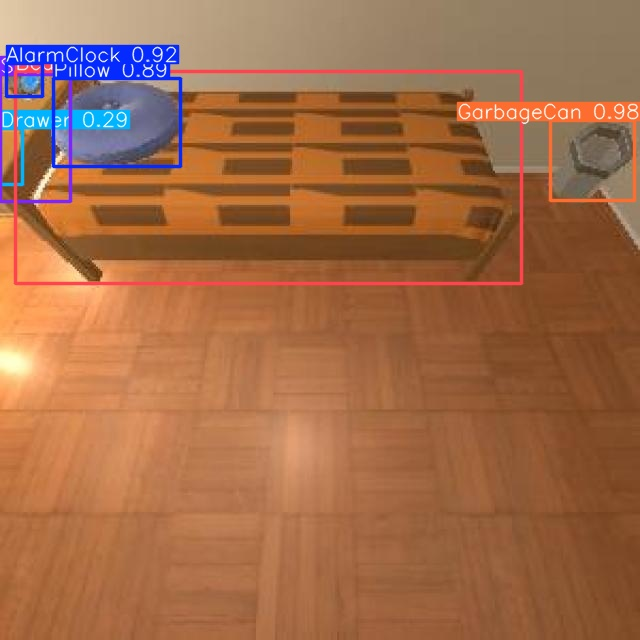

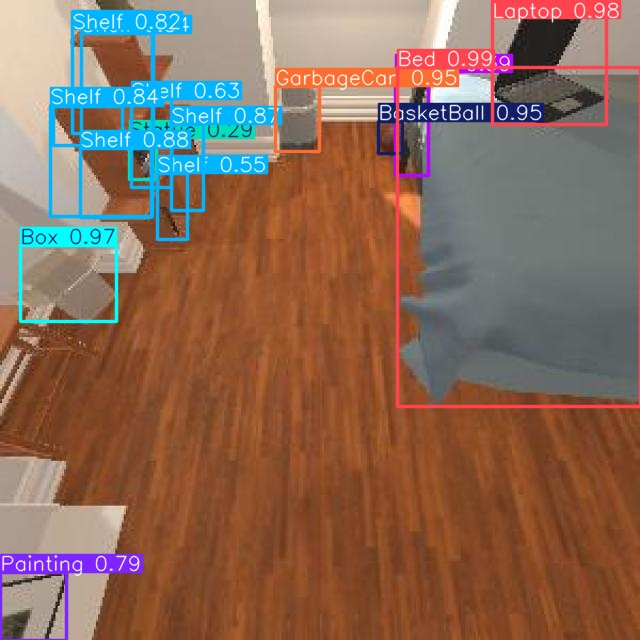

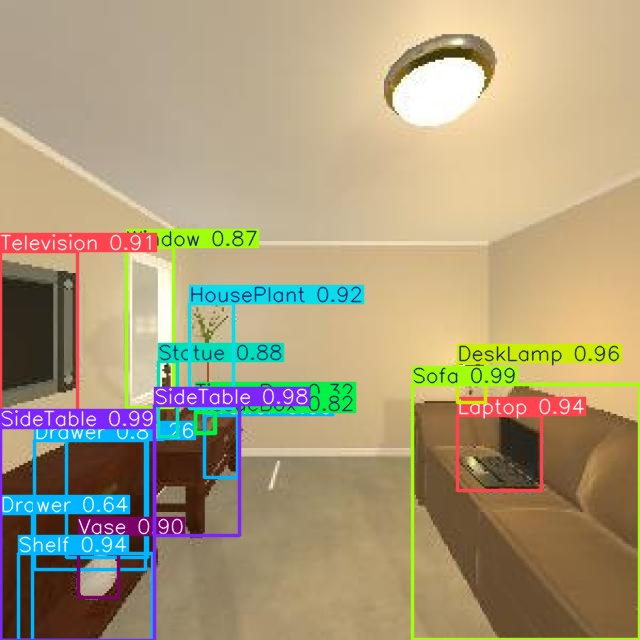

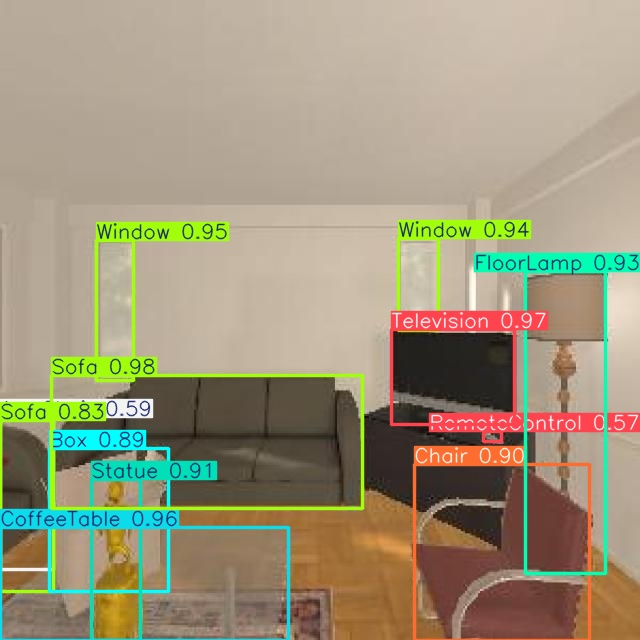

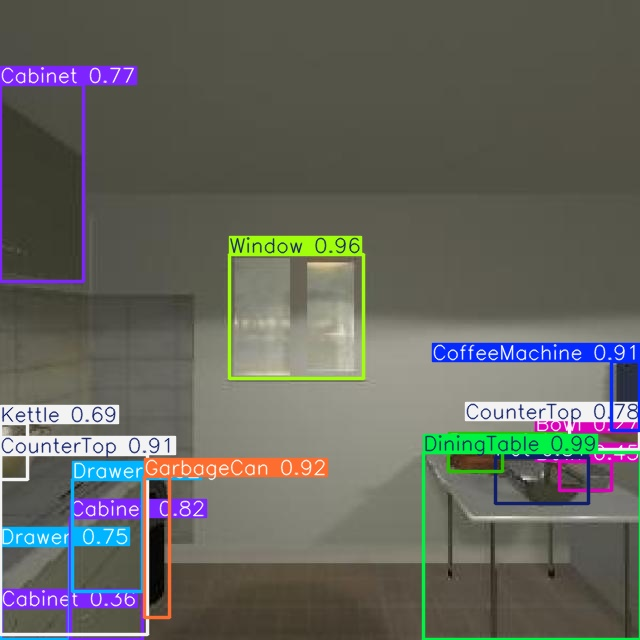

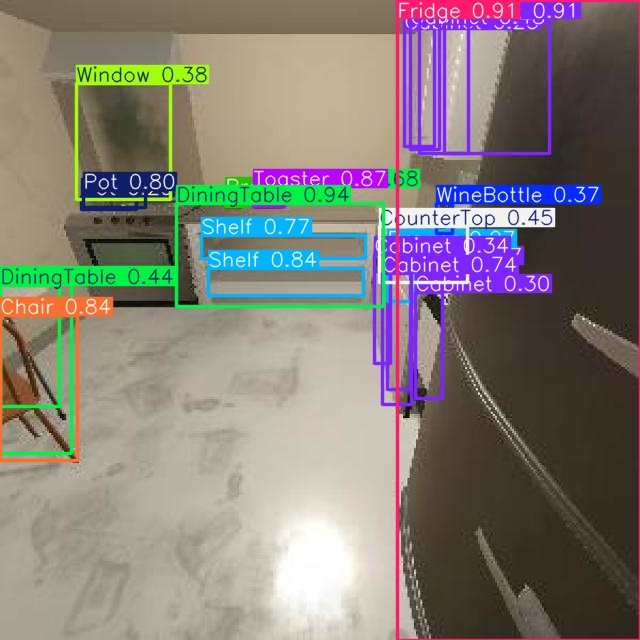

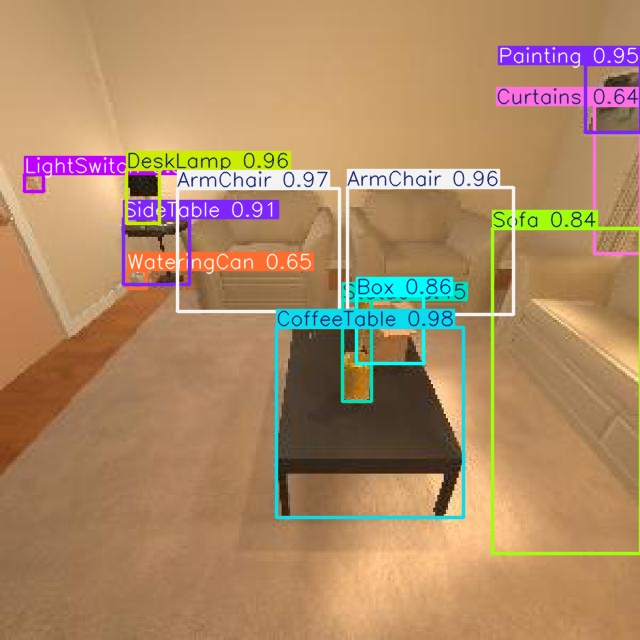

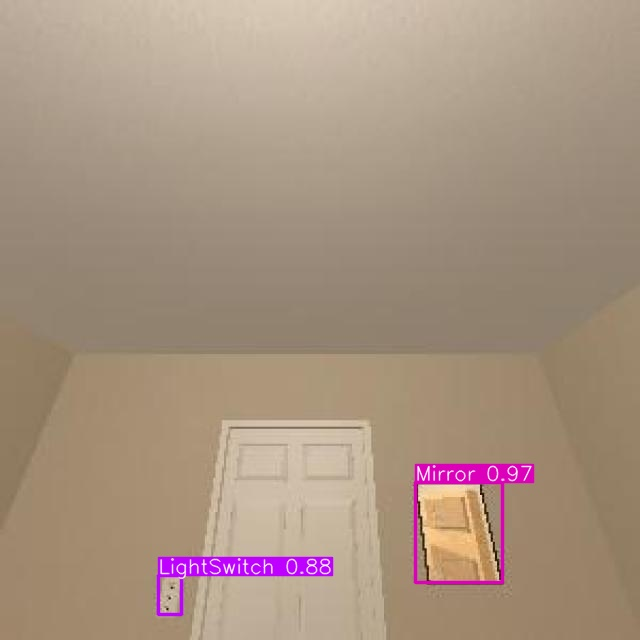

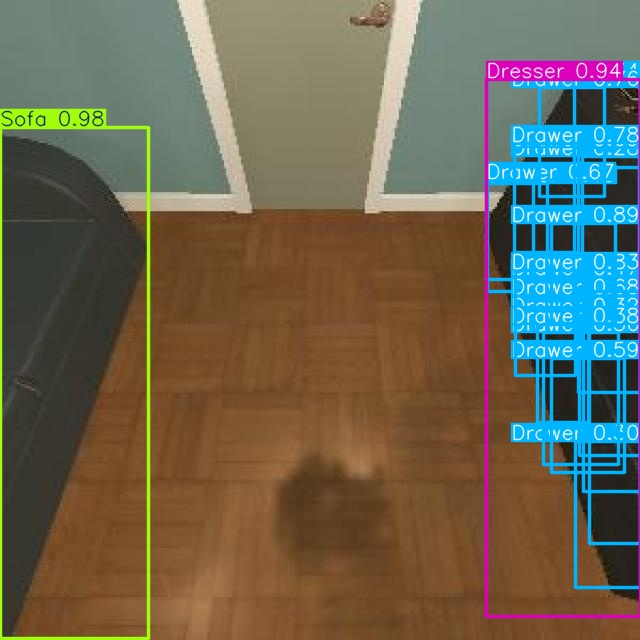

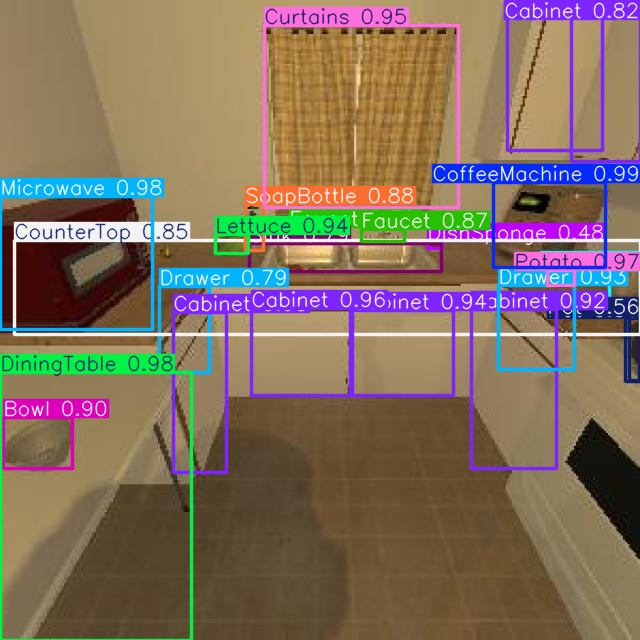

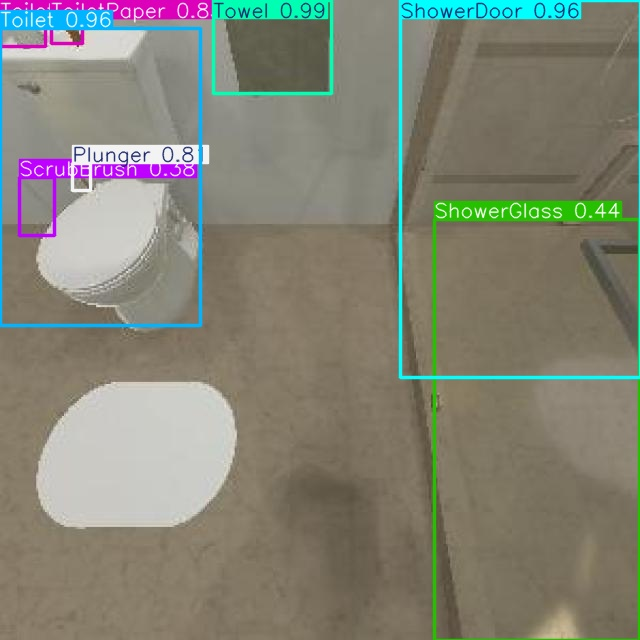

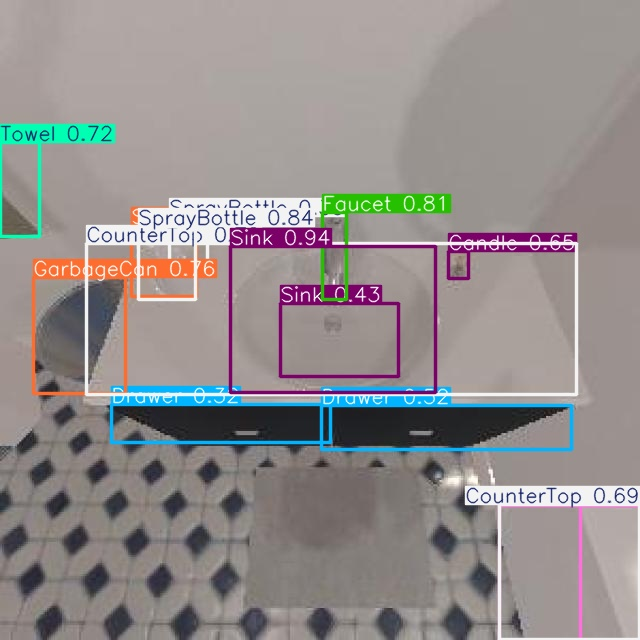

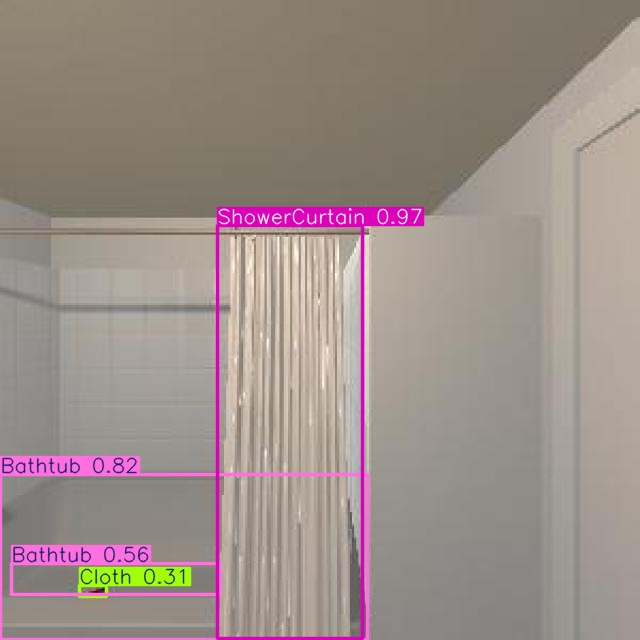

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:13]:
    display(IPyImage(filename=img, width=600))
    print("\n")

Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,647,891 parameters, 0 gradients, 6.6 GFLOPs

image 1/1 /content/9gFNBQJmk9WmdYWtkwfo45.jpg: 384x640 3 ArmChairs, 7 Chairs, 3 CoffeeTables, 1 DiningTable, 1 Drawer, 3 HousePlants, 1 Laptop, 1 Painting, 1 Pillow, 1 SideTable, 2 Sofas, 1 Window, 53.2ms
Speed: 13.8ms preprocess, 53.2ms inference, 313.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


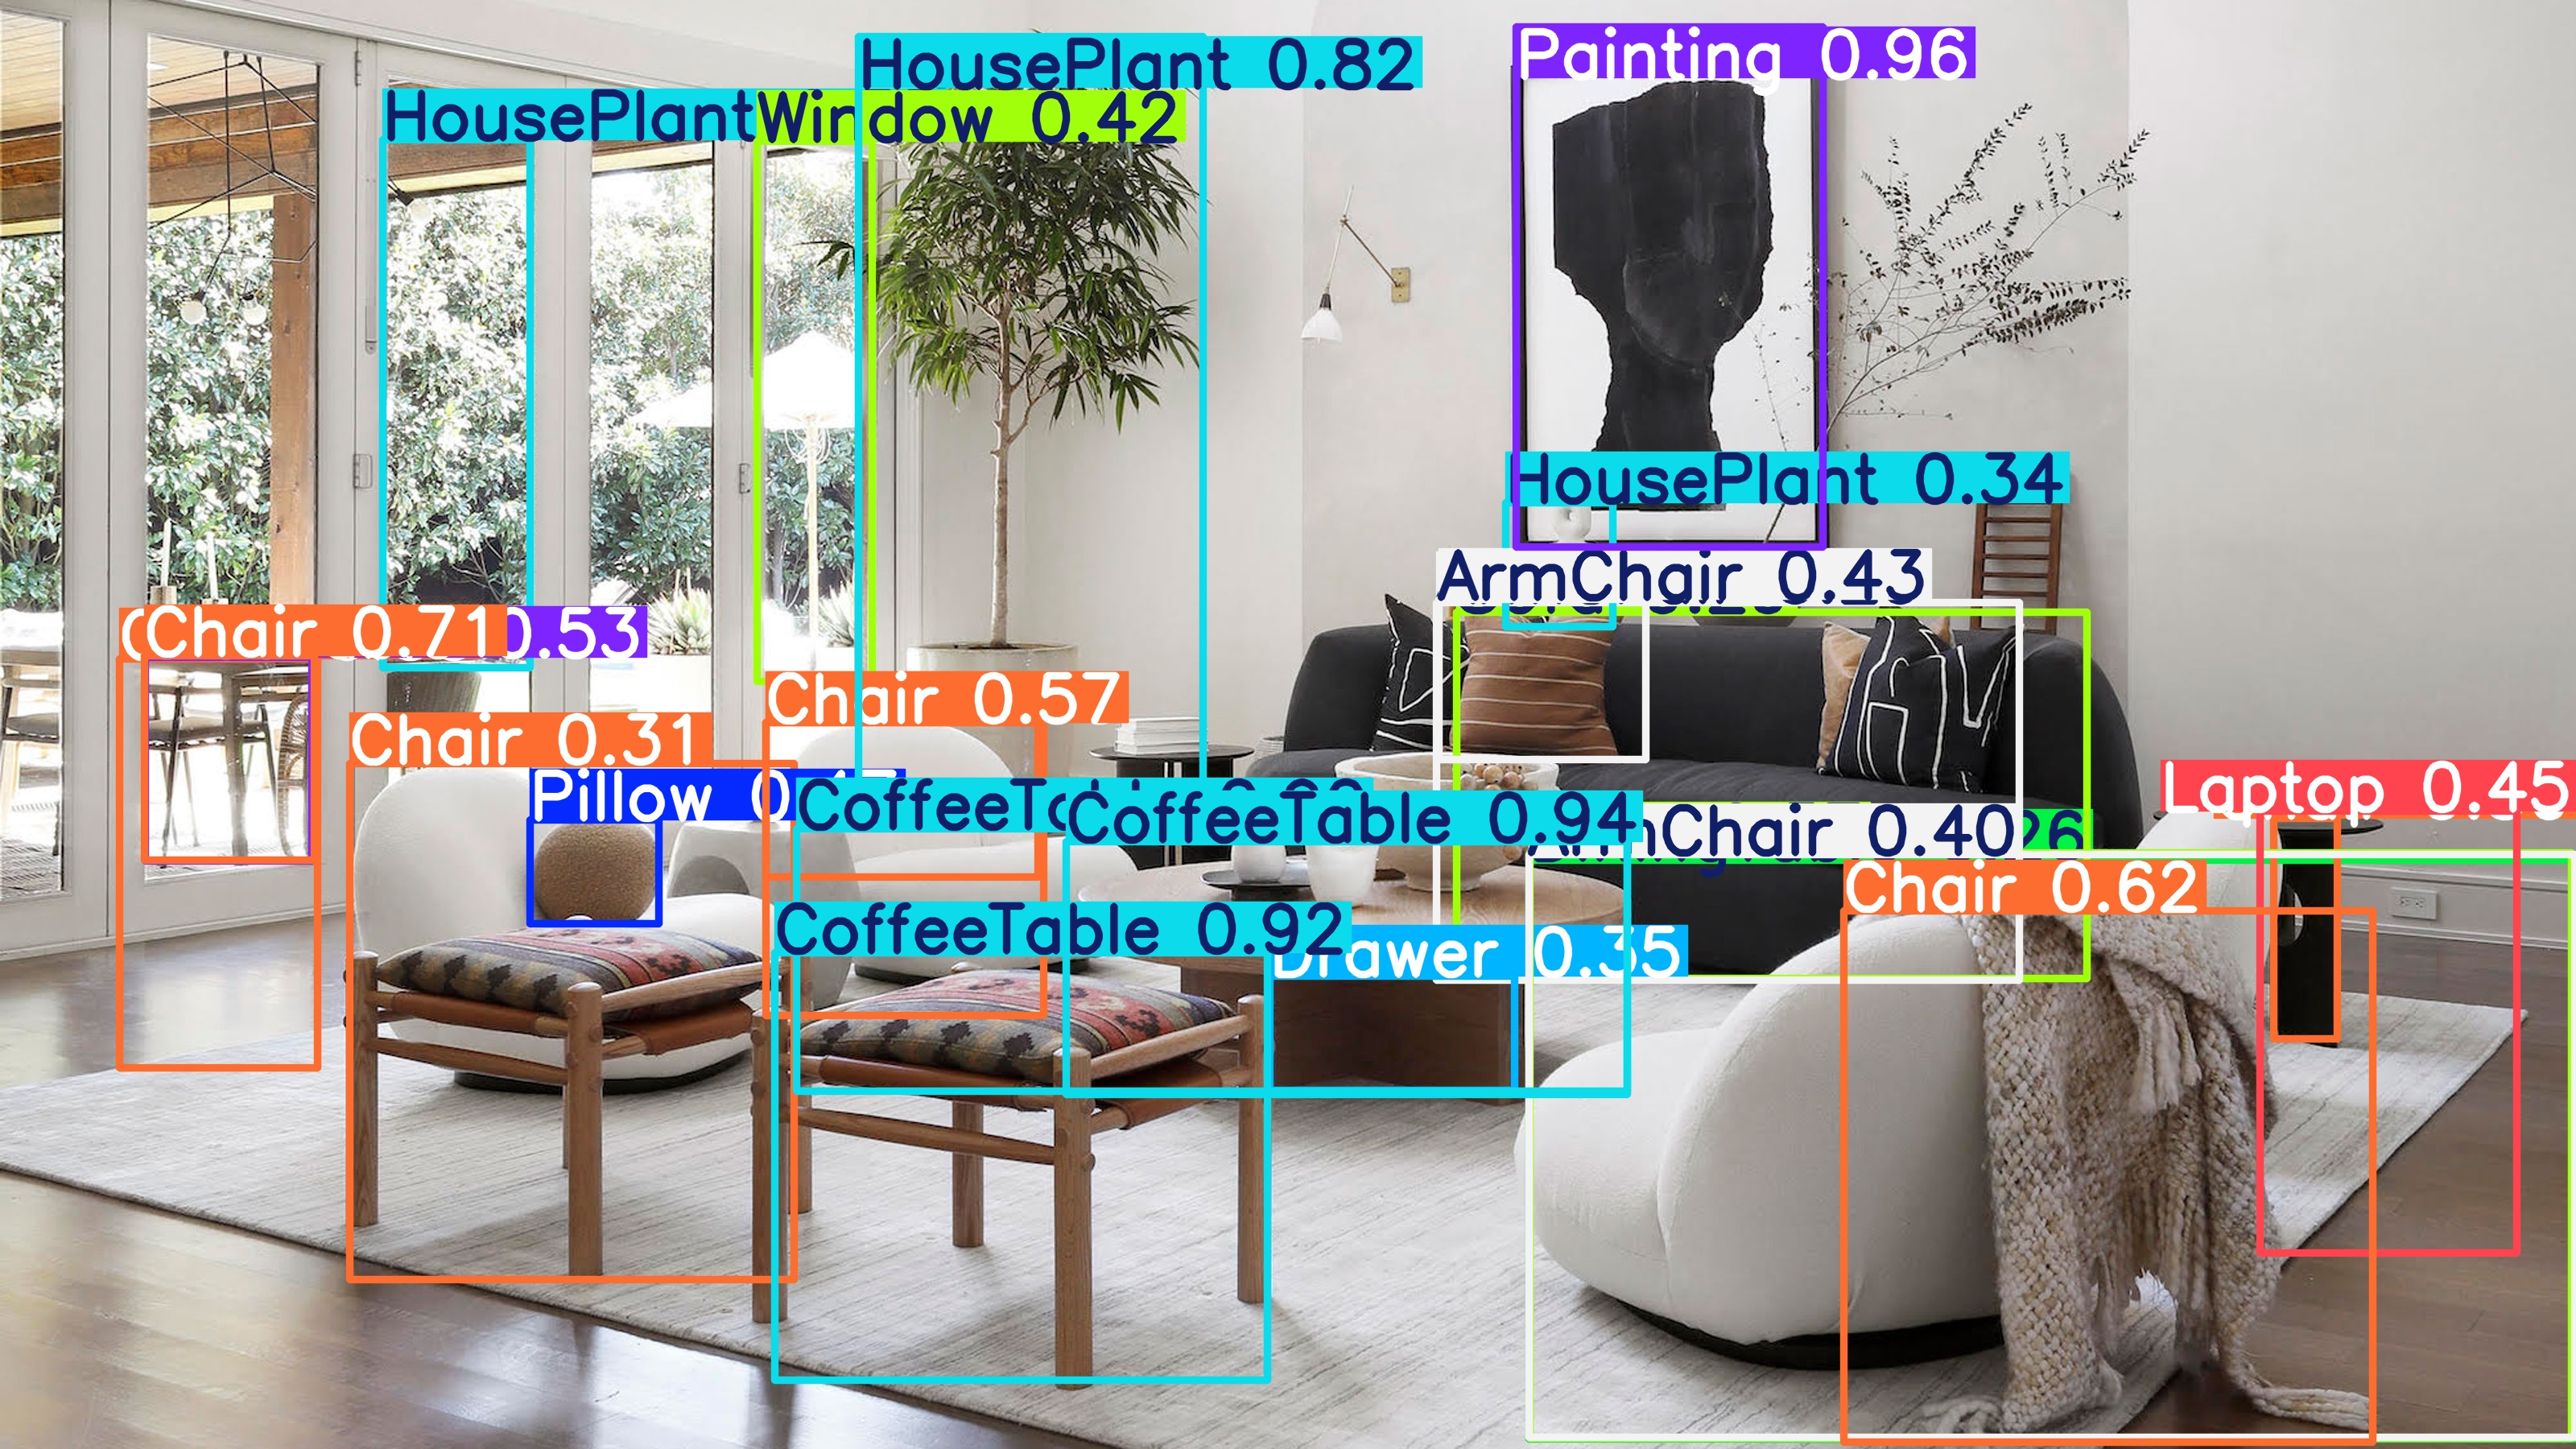

In [ ]:
# !yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='https://havenly.com/blog/wp-content/uploads/2024/02/kyliefitts_havenly_tundeoyeneyin_2-5-1500x970.jpg' save=True

!yolo task=detect mode=predict model=/content/HouseHold.pt conf=0.25 source='/content/9gFNBQJmk9WmdYWtkwfo45.jpg' save=True


import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'/content/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=1000))

In [ ]:
import time
from google.colab import files

# Step 1: Define path to the model weights
# Corrected path: Assuming training output is in 'runs/detect/train'
model_weights_path = 'runs/detect/train/weights/best.pt'
# If your training output is in 'runs/detect/train2', then keep the original path

# Step 2: Start the timer
start_time = time.time()

# Download the model weights
files.download(model_weights_path)

# Step 3: Calculate the time taken to download
end_time = time.time()
download_time = end_time - start_time

# Print the download time
print(f"Model weights downloaded successfully in {download_time:.2f} seconds.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model weights downloaded successfully in 0.00 seconds.
